In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
dataset_path = r"emg_dataset\EMG hand gestures dataset"

In [3]:
data = []
labels = []

In [7]:
for subject in os.listdir(dataset_path):

    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):

        for file in os.listdir(subject_path):

            if file.endswith(".txt"):

                label = file.replace(".txt", "")

                # Use only Open, Close, Grip
                if label in ['0', '1', '2']:

                    file_path = os.path.join(subject_path, file)

                    signal = np.loadtxt(file_path)

                    signal = signal.flatten()

                    data.append(signal)

                    labels.append(label)

In [9]:
print("Total Samples:", len(data))
print("Labels:", set(labels))

Total Samples: 24
Labels: {'1', '0', '2'}


In [11]:
filtered_data = []

for signal in data:

    filtered_signal = savgol_filter(
        signal,
        window_length=5,
        polyorder=2
    )

    filtered_data.append(filtered_signal)

In [13]:
X = pd.DataFrame(filtered_data)

y = pd.Series(labels)

print(X.shape)
print(y.shape)

(24, 89740)
(24,)


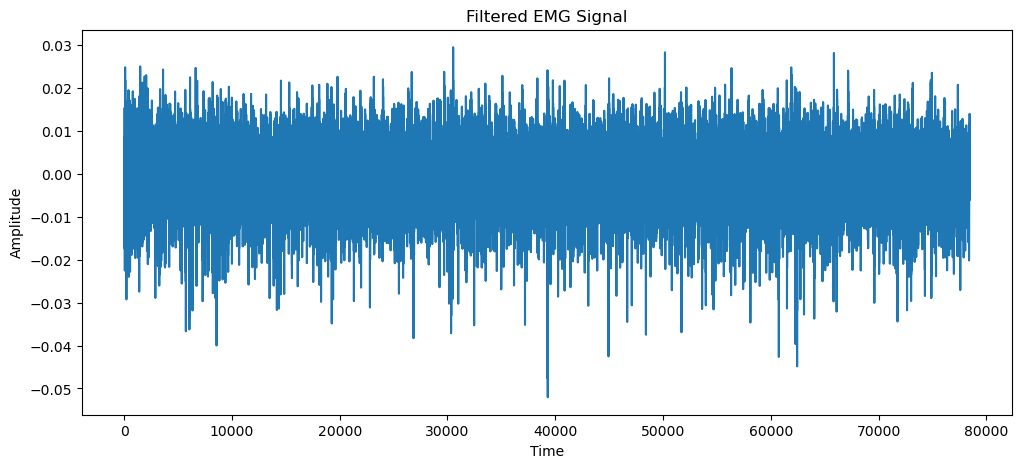

In [15]:
plt.figure(figsize=(12,5))

plt.plot(X.iloc[0])

plt.title("Filtered EMG Signal")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
y_pred = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2

    accuracy                           0.40         5
   macro avg       0.13      0.33      0.19         5
weighted avg       0.16      0.40      0.23         5



C:\Users\rites\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rites\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rites\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


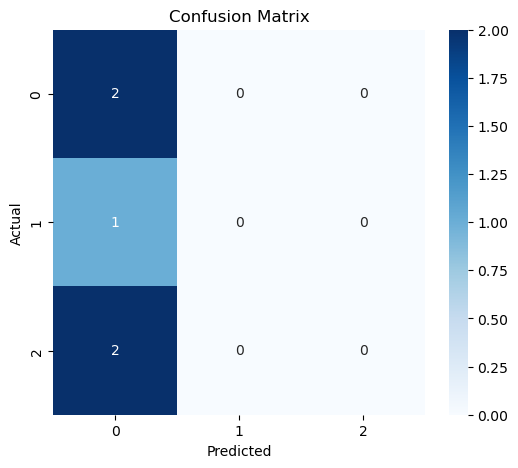

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [31]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

In [33]:
gesture_map = {
    '0': 'Open',
    '1': 'Close',
    '2': 'Grip'
}

In [35]:
predicted_gesture = gesture_map.get(
    prediction[0],
    prediction[0]
)

print("Predicted Gesture:", predicted_gesture)

Predicted Gesture: Open
